# Distance estimation from multi-tone phase

A transmitter emits $N$ orthogonal tones at baseband frequencies

$$f_k \;=\; k\,\Delta f, \qquad k = 0, 1, \dots, N-1, \qquad \Delta f = 1\,\mathrm{MHz}.$$

Each tone propagates over a (one-way) distance $d$, accumulating a phase

$$\phi_k \;=\; -2\pi f_k\, \tau, \qquad \tau = d/c.$$

So **phase is linear in frequency** with slope $-2\pi\tau$. The receiver demodulates each tone, measures its phase $\phi_k$, fits a line, and recovers

$$\boxed{\;\hat{d} \;=\; -\,\frac{c}{2\pi}\,\frac{d\phi}{df}.\;}$$

#### Assumptions

- All $N$ tones are transmitted simultaneously as one OFDM-like symbol of duration $T = 1/\Delta f$ (so the tones are mutually orthogonal over the symbol).
- Sample rate $f_s = \mathrm{OSR}\cdot N\,\Delta f$ with $\mathrm{OSR}=8$, giving $M = \mathrm{OSR}\cdot N$ samples per symbol.
- Receiver demodulation = DFT bin extraction (correlate with $e^{-j2\pi f_k t}$ over $[0,T]$).

#### Unambiguous range

Phase wraps every $2\pi$, so consecutive tones must differ by less than $\pi$ for unwrapping to succeed. That gives

$$d_\text{max} \;=\; \frac{c}{2\Delta f} \;=\; \frac{3\!\times\!10^8}{2\cdot 10^6} \;=\; 150\,\mathrm{m}.$$

#### Frequency offset

If the Rx local oscillator is offset by $\delta f$ from the Tx LO, adjacent tones leak into each other (**inter-carrier interference, ICI**), which biases the per-tone phase and therefore the recovered distance.

We simulate this below and quantify the bias as a function of $\delta f$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

c = 3e8                              # speed of light (m/s)
N = 80                               # number of orthogonal tones
delta_f = 1e6                        # tone spacing (Hz)
OSR = 4                              # oversampling ratio
fs = OSR * N * delta_f               # sample rate (Hz)
T_sym = 1 / delta_f                  # OFDM symbol duration (s)
M = OSR * N                          # samples per symbol
t = np.arange(M) / fs                # sample times within one symbol
freqs = np.arange(N) * delta_f       # tone frequencies (baseband)
d_max = c / (2 * delta_f)            # max unambiguous distance (m)

print(f"N = {N} tones,  delta_f = {delta_f/1e6:.1f} MHz,  OSR = {OSR}")
print(f"fs = {fs/1e6:.0f} MHz,  M = {M} samples,  T = {T_sym*1e6:.2f} us")
print(f"unambiguous range: 0 < d < {d_max:.1f} m")


def simulate(d_true, freq_offset=0.0, snr_db=np.inf, delay=1e-9, n_tones=None, rng=None):
    """Single-symbol simulation: Tx multitone -> channel -> Rx -> distance estimate.

    Parameters
    ----------
    d_true      : true Tx-Rx distance (m)
    freq_offset : Tx-Rx LO frequency mismatch (Hz)
    snr_db      : per-sample SNR in dB (np.inf for no noise)
    n_tones     : optional override of the global N. If provided, fs/M/t/freqs
                  are recomputed for this run only.
    rng         : numpy Generator (defaults to a fresh one per call)

    Returns
    -------
    d_hat   : estimated distance (m)
    phases  : (N,) unwrapped per-tone phases used for the slope fit
    phasors : (N,) complex correlator outputs
    slope, intercept : linear fit of phase vs frequency
    """
    rng = rng if rng is not None else np.random.default_rng()

    # Resolve N and dependent quantities (override module defaults if n_tones given).
    if n_tones is None:
        N_, fs_, M_, t_, freqs_ = N, fs, M, t, freqs
    else:
        N_ = int(n_tones)
        fs_ = OSR * N_ * delta_f
        M_ = OSR * N_
        t_ = np.arange(M_) / fs_
        freqs_ = np.arange(N_) * delta_f

    # Generate N orthogonal tones, equal amplitude, random phase offsets
    # `delay` now comes from the function parameter (default 1e-9).
    phi = 2 * np.pi * delay / T_sym
    phase_offsets = np.random.uniform(0, phi, N_)
    TX = np.zeros(M_).astype(np.complex64)
    TX[:N_] = np.exp(-1j*phase_offsets) 

    # Apply delay    
    tau = d_true / c
    fft_bins = np.fft.fftfreq(M_, d=1/fs_)

    # Time-domain signal
    rx = np.fft.ifft( TX * np.exp(-2j * np.pi * fft_bins * tau))

    # Tx-Rx LO frequency offset rotates the received signal at rate -freq_offset.
    if freq_offset != 0.0:
        rx = rx * np.exp(-2j * np.pi * freq_offset * t_)

    # Complex AWGN at the requested SNR.
    if np.isfinite(snr_db):
        sig_pow = np.mean(np.abs(rx)**2)
        noise_pow = sig_pow / 10**(snr_db / 10)
        n = (rng.standard_normal(M_) + 1j * rng.standard_normal(M_)) * np.sqrt(noise_pow / 2)
        rx = rx + n

    # FFT demodulation: bin index j corresponds to frequency j*fs/M = j*delta_f,
    # so bin k is exactly tone f_k = k*delta_f.
    phasors = np.fft.fft(rx)[:N_]

    # Unwrap phase across tones (phase decreases linearly with frequency for d > 0).
    phases = np.unwrap(np.angle(phasors))

    # Linear fit: slope of phase vs frequency.
    #slope = np.mean(np.diff(phases))/delta_f
    slope, intercept = np.polyfit(freqs_, phases, 1) # more precise
    d_hat = -c * slope / (2 * np.pi)

    return d_hat, phases, phasors, slope, intercept


N = 80 tones,  delta_f = 1.0 MHz,  OSR = 4
fs = 320 MHz,  M = 320 samples,  T = 1.00 us
unambiguous range: 0 < d < 150.0 m


### Single-shot sanity check

Pick a true distance and verify the estimator recovers it (no offset, no noise). Then visualize the phase-vs-frequency line that the slope fit acts on.


true     : 3.0000 m
estimate : 2.9999 m   (residual: -1.133e-04 m)
true     : 3.0000 m
estimate : 2.9910 m   (residual: -9.012e-03 m)


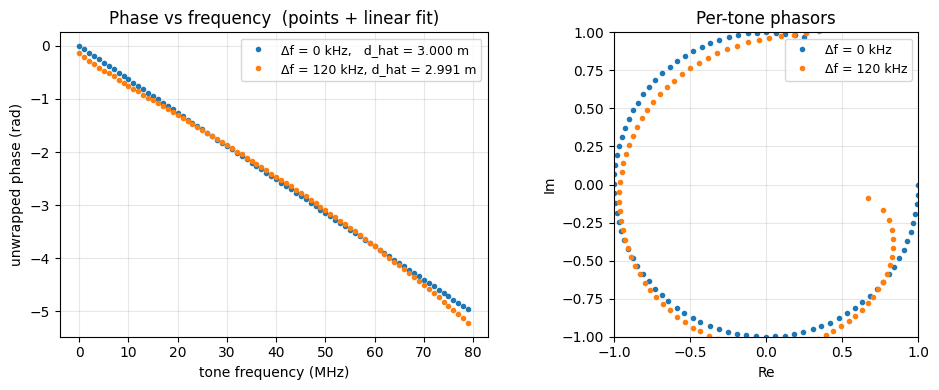

In [2]:
d_true = 3.0   # m
snr_db = np.inf
freq_offset_1 = 120e3   # Hz

# Clean recovery: no offset, no noise.
d_hat_0, phases_0, phasors_0, m_0, b_0 = simulate(d_true, snr_db=snr_db, freq_offset=0)
print(f"true     : {d_true:.4f} m")
print(f"estimate : {d_hat_0:.4f} m   (residual: {d_hat_0 - d_true:+.3e} m)")

d_hat_1, phases_1, phasors_1, m_1, b_1 = simulate(d_true, snr_db=snr_db, freq_offset=freq_offset_1)
print(f"true     : {d_true:.4f} m")
print(f"estimate : {d_hat_1:.4f} m   (residual: {d_hat_1 - d_true:+.3e} m)")

# Pin colors explicitly so points and fit lines (and right-panel phasors) match
# across both axes -- avoids matplotlib's prop-cycle advancing on each plot call.
c0, c1 = 'C0', 'C1'

plt.figure(figsize=(10, 4))

ax1 = plt.subplot(121)
# Phase points + fit lines (slope, intercept come straight from simulate()).
ax1.plot(freqs/1e6, phases_0, '.', color=c0, label=f'Δf = 0 kHz,   d_hat = {d_hat_0:.3f} m')
ax1.plot(freqs/1e6, phases_1, '.', color=c1, label=f'Δf = {freq_offset_1/1e3:.0f} kHz, d_hat = {d_hat_1:.3f} m')
ax1.set_xlabel('tone frequency (MHz)')
ax1.set_ylabel('unwrapped phase (rad)')
ax1.set_title('Phase vs frequency  (points + linear fit)')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)

ax2 = plt.subplot(122)
ax2.plot(np.real(phasors_0), np.imag(phasors_0), '.', color=c0, label='Δf = 0 kHz')
ax2.plot(np.real(phasors_1), np.imag(phasors_1), '.', color=c1, label=f'Δf = {freq_offset_1/1e3:.0f} kHz')
ax2.set_xlim(-1, 1)
ax2.set_ylim(-1, 1)
ax2.set_aspect('equal')
ax2.set_xlabel('Re')
ax2.set_ylabel('Im')
ax2.set_title('Per-tone phasors')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


### Frequency-offset sweep

Now let the Rx LO be offset from the Tx LO by $\delta f$, with no noise. Sweep $\epsilon = \delta f / \Delta f$ from $0$ to $\sim 0.5$ and record the recovered distance.

Two regimes to expect:

1. **Small $\epsilon$**: ICI from adjacent tones is small (sinc rolls off quickly), so the bias is small.
2. **$\epsilon \to \pm 0.5$**: each tone is leaking equally into its neighbors and the demodulator effectively half-locks onto a different frequency — bias diverges and unwrapping can fail.


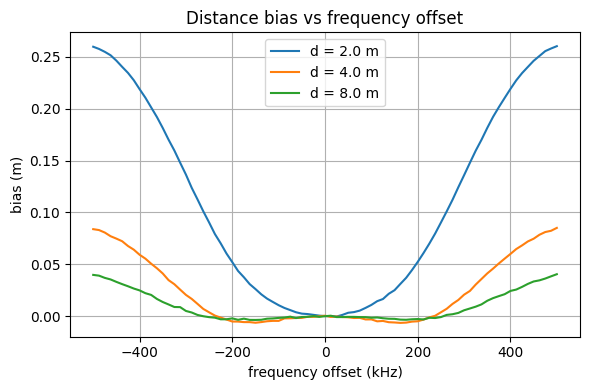

In [3]:
# Sweep the carrier-frequency offset over +/- half the tone spacing.
plt.figure(figsize=(6, 4))
freq_offsets = np.linspace(-0.5 * delta_f, 0.5 * delta_f, 81)  # Hz
distances = [2.0, 4.0, 8.0]
for d_true in distances:
    biases = np.zeros_like(freq_offsets)
    for i, foff in enumerate(freq_offsets):
        d_hat_i, *_ = simulate(d_true, freq_offset=foff)
        biases[i] = d_hat_i - d_true
    plt.plot(freq_offsets / 1e3, biases, label=f'd = {d_true} m')
plt.title('Distance bias vs frequency offset')
plt.xlabel('frequency offset (kHz)')
plt.ylabel('bias (m)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


### Interactive sweep

Drag the sliders to see how the phase line and the recovered distance respond to **SNR** (0 – 30 dB) and **carrier-frequency offset** (0 – 120 kHz). Noise is reseeded to the same RNG state on every redraw, so changes you see are due to the sliders, not luck.


In [ ]:
from ipywidgets import interact, FloatSlider, IntSlider

# Slider bounds (kept as constants so the y-limit calculation can reference them).
D_MIN_M, D_MAX_M = 1.0, 40.0
SNR_MIN_DB, SNR_MAX_DB = -6.0, 80.0

@interact(
    snr_db          = FloatSlider(min=SNR_MIN_DB, max=SNR_MAX_DB, step=1,   value=20, description='SNR (dB)'),
    freq_offset_khz = FloatSlider(min=0,          max=240,        step=10,  value=0,  description='Δf_off (kHz)'),
    n_tones         = IntSlider  (min=2,          max=80,         step=2,   value=80, description='# tones'),
    d_true_m        = FloatSlider(min=D_MIN_M,    max=D_MAX_M,    step=1,   value=3,  description='d (m)'),
    delay_ns        = FloatSlider(min=0,          max=100,        step=1,   value=0,  description='delay (ns)'),
)
def show(snr_db, freq_offset_khz, n_tones, d_true_m, delay_ns):
    # Reseed each call so slider movement -- not luck -- drives the visible change.
    rng = np.random.default_rng(0)
    d_hat, phases, _, m, b = simulate(d_true_m, snr_db=snr_db,
                                      freq_offset=freq_offset_khz * 1e3,
                                      n_tones=n_tones, delay=delay_ns * 1e-9, rng=rng)
    freqs_local = np.arange(n_tones) * delta_f

    c0 = 'C0'
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(freqs_local/1e6, phases, '.', color=c0,
            label='measured phases')
    ax.plot(freqs_local/1e6, m * freqs_local + b, '-', color='red', alpha=0.5, linewidth=1.2,
            label=r'estimated $\Delta\phi / \Delta f$')
    # True-slope line, anchored to the same intercept b so the slope difference is what's visible.
    true_slope = -2 * np.pi * d_true_m / c
    ax.plot(freqs_local/1e6, true_slope * freqs_local + b, '--', color='C2', alpha=0.8, linewidth=1.2,
            label=fr'true $\Delta\phi / \Delta f$  (d = {d_true_m:.2f} m)')
    ax.set_xlabel('tone frequency (MHz)')
    ax.set_ylabel('unwrapped phase (rad)')
    ax.set_title(f'SNR = {snr_db:.0f} dB,  Δf = {freq_offset_khz:.0f} kHz,  N = {n_tones},'
                 f'  true d = {d_true_m:.2f} m,   est d = {d_hat:.3f} m)')
    # Fix y-limits to accommodate the *largest* reachable phase magnitude
    # (worst case is d = D_MAX_M at the highest tone for the current N), so the
    # axis doesn't jump around as the d slider moves.
    phase_mag_max = 2 * np.pi * (n_tones - 1) * delta_f * D_MAX_M / c
    #ax.set_ylim(-1 * phase_mag_max, 0.1 * phase_mag_max)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.show()


interactive(children=(FloatSlider(value=20.0, description='SNR (dB)', max=80.0, min=-6.0, step=1.0), FloatSlid…